M.Talha Ramzan
===
2330-0141
===
lab Mid Machine learning
===

In [13]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, mean_squared_error,mean_absolute_error, confusion_matrix, r2_score

In [4]:
# Question 1: Load dataset and display total rows, columns, and data types

df = pd.read_excel("/content/Concrete_Data.xls")

print("Rows and Columns:", df.shape)
print("\nData Types:\n", df.dtypes)

Rows and Columns: (1030, 9)

Data Types:
 Cement (component 1)(kg in a m^3 mixture)                float64
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    float64
Fly Ash (component 3)(kg in a m^3 mixture)               float64
Water  (component 4)(kg in a m^3 mixture)                float64
Superplasticizer (component 5)(kg in a m^3 mixture)      float64
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     float64
Fine Aggregate (component 7)(kg in a m^3 mixture)        float64
Age (day)                                                  int64
Concrete compressive strength(MPa, megapascals)          float64
dtype: object


In [5]:
# Question 2: Rename columns and display first 5 rows

df.columns = ['Cement', 'BlastFurnace_Slag', 'Fly_Ash', 'Water', 'Superplasticizer',
              'Coarse_Aggregate', 'Fine_Aggregate', 'Age', 'Strength']

df.head()

,Cement,BlastFurnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [6]:
# Question 3: Check missing values and handle them

print(df.isnull().sum())

df = df.fillna(df.mean())

# Explanation:
# We use mean because data is numerical and mean keeps distribution stable.

Cement               0
BlastFurnace_Slag    0
Fly_Ash              0
Water                0
Superplasticizer     0
Coarse_Aggregate     0
Fine_Aggregate       0
Age                  0
Strength             0
dtype: int64


In [7]:
# Question 4: Unique value count for Age

unique_age = df['Age'].nunique()
print("Unique values in Age:", unique_age)

# Explanation:
# More unique values mean Age is a continuous variable, not categorical.

Unique values in Age: 14


In [8]:
# Question 5: Apply MinMaxScaler

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X = df.drop('Strength', axis=1)
y = df['Strength']

X_scaled = scaler.fit_transform(X)

# Explanation:
# Scaling is not always required for regression, but helps when features have different ranges.



**Part B**

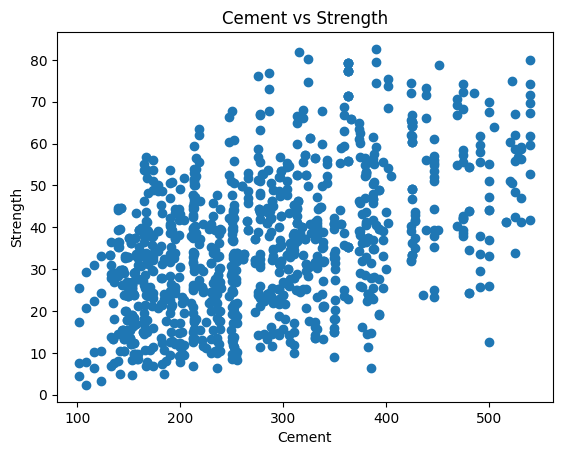

In [9]:
# Question: Scatter plot Cement vs Strength

plt.scatter(df['Cement'], df['Strength'])
plt.xlabel("Cement")
plt.ylabel("Strength")
plt.title("Cement vs Strength")
plt.show()

# Answers:
# Relationship: Slightly non-linear (not perfectly straight)
# Better Model: Polynomial Regression
# Reason: Data shows curvature, so polynomial can capture non-linear pattern better.

**Part C**

In [14]:
# Question 1: Linear Regression with evaluation metrics

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred)
mae_lr = mean_absolute_error(y_test, y_pred)
r2_lr = r2_score(y_test, y_pred)

print("Linear Regression Results:")
print("MSE:", mse_lr)
print("MAE:", mae_lr)
print("R2:", r2_lr)

Linear Regression Results:
MSE: 95.97548435337708
MAE: 7.745392872421345
R2: 0.627541605542902


In [15]:
# Question 2: Polynomial Regression (degree 2 and 3)

from sklearn.preprocessing import PolynomialFeatures

# Degree 2
poly2 = PolynomialFeatures(degree=2)
X_poly2 = poly2.fit_transform(X_scaled)

X_train2, X_test2, y_train2, y_test2 = train_test_split(X_poly2, y, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X_train2, y_train2)
y_pred2 = model2.predict(X_test2)

mse2 = mean_squared_error(y_test2, y_pred2)
mae2 = mean_absolute_error(y_test2, y_pred2)
r22 = r2_score(y_test2, y_pred2)

# Degree 3
poly3 = PolynomialFeatures(degree=3)
X_poly3 = poly3.fit_transform(X_scaled)

X_train3, X_test3, y_train3, y_test3 = train_test_split(X_poly3, y, test_size=0.2, random_state=42)

model3 = LinearRegression()
model3.fit(X_train3, y_train3)
y_pred3 = model3.predict(X_test3)

mse3 = mean_squared_error(y_test3, y_pred3)
mae3 = mean_absolute_error(y_test3, y_pred3)
r23 = r2_score(y_test3, y_pred3)

print("Degree 2 -> MSE:", mse2, "MAE:", mae2, "R2:", r22)
print("Degree 3 -> MSE:", mse3, "MAE:", mae3, "R2:", r23)

# Better model:
# Compare R2 (higher is better) and MSE (lower is better)

Degree 2 -> MSE: 55.58992637475128 MAE: 5.969643801944325 R2: 0.7842685049726492
Degree 3 -> MSE: 40.27107281741973 MAE: 4.692859041646867 R2: 0.8437173906889144


In [18]:
# Question 3: Comparison Table

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Polynomial (deg=2)", "Polynomial (deg=3)"],
    "MSE": [mse_lr, mse2, mse3],
    "MAE": [mae_lr, mae2, mae3],
    "R2 Score": [r2_lr, r22, r23]
})

comparison

,Model,MSE,MAE,R2 Score
0,Linear Regression,95.975484,7.745393,0.627542
1,Polynomial (deg=2),55.589926,5.969644,0.784269
2,Polynomial (deg=3),40.271073,4.692859,0.843717


# Question 4: Conceptual Question

# Ridge Regression:
Solves overfitting by adding penalty on large coefficients.

# Lasso Regression:
Solves overfitting and also performs feature selection by making some coefficients zero.

# Key Difference:
Ridge shrinks coefficients, Lasso can make some coefficients exactly zero.

**Question 2: Dimensionality Reduction, PCA & LDA**
=====


In [19]:
# Question 1: Load dataset and display feature names, target column, missing values

import pandas as pd

df = pd.read_csv("/content/train.csv")

# Features and target
print("Features:\n", df.columns[:-1])
print("\nTarget Column:\n", df.columns[-1])

# Missing values check
print("\nMissing Values:\n", df.isnull().sum())

Features:
 Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi'],
      dtype='object')

Target Column:
 price_range

Missing Values:
 battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64


In [20]:
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [21]:
# Question 2: Why scaling is needed + Apply MinMaxScaler

from sklearn.preprocessing import MinMaxScaler

# Answer:
# PCA depends on variance. If features have different scales, large-scale features dominate PCA.
# So scaling is necessary.

X = df.drop('price_range', axis=1)
y = df['price_range']

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [22]:
# Question 3: PCA with 2 and 3 components

from sklearn.decomposition import PCA

# PCA with 2 components
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)

print("PCA 2 Components Shape:", X_pca2.shape)
print("Explained Variance (2 PCs):", pca2.explained_variance_ratio_)

# PCA with 3 components
pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_scaled)

print("\nPCA 3 Components Shape:", X_pca3.shape)
print("Explained Variance (3 PCs):", pca3.explained_variance_ratio_)

PCA 2 Components Shape: (2000, 2)
Explained Variance (2 PCs): [0.13258747 0.09960955]

PCA 3 Components Shape: (2000, 3)
Explained Variance (3 PCs): [0.13258747 0.09960955 0.09820247]


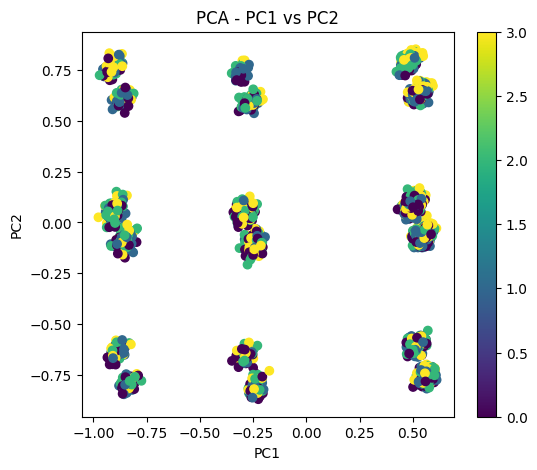

In [23]:
# Question 4: PCA scatter plot (PC1 vs PC2)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.scatter(X_pca2[:,0], X_pca2[:,1], c=y, cmap='viridis')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - PC1 vs PC2")
plt.colorbar()
plt.show()

# Answers:
# - Classes: Partially overlapping
# - Meaning: PCA is unsupervised, so it does not perfectly separate classes

In [ ]:
# Question 3: Conceptual (LDA)

# LDA (Linear Discriminant Analysis) is a supervised learning method,
# meaning the data contains labels (output classes) along with input features.

# It uses these labels to find the best direction that separates different classes.

# PCA (Principal Component Analysis) is unsupervised,
# so it does NOT use output labels and only works with input features.

# LDA is best for classification problems because it maximizes class separability.

**PART C — CONCEPTUAL**
====

In [24]:
# Question 1: Explained Variance

pc1 = 0.62
pc2 = 0.18

total_variance = pc1 + pc2
print("Total Variance Captured:", total_variance)

Total Variance Captured: 0.8


**Question 3: KNN + Random Forest Classification**
=====

PART A — CLASSIFICATION (KNN & RANDOM FOREST)

In [26]:
# Question 1: Load dataset and prepare features/target

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv("/content/train.csv")

X = df.drop("price_range", axis=1)
y = df["price_range"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**KNN (K = 3 and K = 57)**

In [28]:
# KNN with K = 3 and K = 57

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

# K = 3
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(X_train, y_train)
pred3 = knn3.predict(X_test)

acc3 = accuracy_score(y_test, pred3)
prec3 = precision_score(y_test, pred3, average='macro')
rec3 = recall_score(y_test, pred3, average='macro')

print("KNN (K=3)")
print("Accuracy:", acc3)
print("Precision:", prec3)
print("Recall:", rec3)

# K = 57
knn57 = KNeighborsClassifier(n_neighbors=57)
knn57.fit(X_train, y_train)
pred57 = knn57.predict(X_test)

acc57 = accuracy_score(y_test, pred57)
prec57 = precision_score(y_test, pred57, average='macro')
rec57 = recall_score(y_test, pred57, average='macro')

print("\nKNN (K=57)")
print("Accuracy:", acc57)
print("Precision:", prec57)
print("Recall:", rec57)


# Usually smaller K like 3 performs better unless data is very noisy

KNN (K=3)
Accuracy: 0.385
Precision: 0.4018397796623603
Recall: 0.37791696528109575

KNN (K=57)
Accuracy: 0.52
Precision: 0.541413092437816
Recall: 0.5153686892817327


**Random Forest**

In [29]:
# Question 2: Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred, average='macro')
rf_rec = recall_score(y_test, rf_pred, average='macro')

print("Random Forest")
print("Accuracy:", rf_acc)
print("Precision:", rf_prec)
print("Recall:", rf_rec)

Random Forest
Accuracy: 0.8925
Precision: 0.8916329841057944
Recall: 0.8914183189998408


**Comparison Table**

In [30]:
# Question 3: Comparison Table

comparison = pd.DataFrame({
    "Model": ["KNN (K=3)", "KNN (K=57)", "Random Forest"],
    "Accuracy": [acc3, acc57, rf_acc],
    "Precision": [prec3, prec57, rf_prec],
    "Recall": [rec3, rec57, rf_rec]
})

comparison

,Model,Accuracy,Precision,Recall
0,KNN (K=3),0.3850,0.401840,0.377917
1,KNN (K=57),0.5200,0.541413,0.515369
2,Random Forest,0.8925,0.891633,0.891418


# Best model
= whichever has highest Accuracy + Recall balance
# Usually Random Forest performs best overall

**PART B — CONCEPTUAL**

In [ ]:
# Question 1: Recall, Precision, and Disease Example

# Recall:
# Measures how many actual positive cases are correctly identified.

# Precision:
# Measures how many predicted positives are actually correct.

# Disease case:
# We choose HIGH RECALL model (e.g., Random Forest)
# Because missing a sick patient is more dangerous than false alarm.

In [ ]:
# Question 2: Why Random Forest is better than Decision Tree?

# Random Forest combines many decision trees.
# It reduces overfitting and improves generalization.
# It also averages results → more stable and accurate predictions.